# moczarr quickstart

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/espg/moczarr/main?labpath=docs%2Fexamples%2Fquickstart.ipynb)

Open a **morton-hive** zarr store as an xarray Dataset, scope it to an
area of interest through coverage arithmetic, use the xdggs `ds.dggs`
accessor, and run a cross-resolution join — all against the small SERC
fixture store committed in this repo (six order-6 shards around the NEON
SERC site, ATL06-shaped synthetic data at cell order 8).

The prose version of this walk-through is the
[quickstart page](https://espg.github.io/moczarr/quickstart/); the store
convention and the lazy index are explained on the
[concepts page](https://espg.github.io/moczarr/concepts/).

## Open a store

One call from store root to Dataset. An S3 store works the same way —
pass `s3://bucket/prefix` (plus `anonymous=True` for public buckets).

In [1]:
import moczarr

STORE = "../../tests/data/serc_hive"  # ← swap this path for the public source.coop store when it lands

ds = moczarr.open_hive(STORE, decode=True)
ds

<xarray.Dataset> Size: 5kB
Dimensions:     (cells: 96)
Coordinates:
    cell_ids    (cells) uint64 768B 238064 238065 238066 ... 239118 239119
  * morton      (cells) uint64 768B 5340987683084697608 ... 5359547439361556488
Dimensions without coordinates: cells
Data variables:
    count       (cells) int32 384B 30 31 6 2 11 9 22 34 30 ... 0 0 0 0 0 0 0 0
    h_q50       (cells) float32 384B 24.4 31.03 26.63 32.05 ... nan nan nan nan
    h_max       (cells) float32 384B 26.6 32.99 30.18 25.69 ... nan nan nan nan
    h_q75       (cells) float32 384B 32.78 32.36 25.53 38.62 ... nan nan nan nan
    h_sigma     (cells) float32 384B 27.28 24.61 29.69 27.95 ... nan nan nan nan
    h_min       (cells) float32 384B 25.92 30.41 31.41 22.01 ... nan nan nan nan
    h_variance  (cells) float32 384B 31.41 28.55 34.17 25.4 ... nan nan nan nan
    h_mean      (cells) float32 384B 29.92 22.49 22.39 28.04 ... nan nan nan nan
    h_q25       (cells) float32 384B 31.59 28.73 39.07 18.92 ... nan nan nan nan
Indexes:
    morton   MortonIndex(level=8, kind=pandas)
Attributes:
    zarr_conventions:  [{'schema_url': 'https://raw.githubusercontent.com/zar...
    dggs:              {'name': 'healpix', 'refinement_level': 8, 'indexing_s...
    morton_hive:       {'spec': 'morton-hive/1', 'cell_order': 8, 'shard_orde...

`morton` is the packed `uint64` morton word (the stored cell identity);
`cell_ids` is the HEALPix NESTED view, fabricated exactly from the words
when the store does not carry it. `decode=True` (the `[xdggs]` extra)
registers the `"morton"` grid so the `ds.dggs` accessor works below.

## Scope to an AOI

An AOI is a morton cover — packed words or decimal strings, mixed orders
allowed. A decimal prefix is a spatial ancestor, so one order-5 id covers
its whole subtree; shards outside the cover are rejected arithmetically
(their leaves are never opened) and rows are trimmed exactly inside
partially-covered shards.

In [2]:
sub = moczarr.open_hive(STORE, aoi=["433142"])
dict(sub.sizes)

{'cells': 48}

## The lazy index

`index_kind="moc"` holds the row domain as an interval set built from
the same coverage arithmetic that selected the leaves. The on-disk
`morton`/`cell_ids` chunks are **never read** — the coordinate is
fabricated on demand, and `sel`/`isel`/alignment run as rank arithmetic
on intervals. The result is value-identical to the materialized
(`index_kind="pandas"`) open.

In [3]:
lazy = moczarr.open_hive(STORE, index_kind="moc")
lazy.xindexes["morton"]

<MortonMocIndex(level=8, ranges=5, size=96)>

## Accessor ops: point lookup and cell boundaries

`sel_latlon` bins points to cells and selects the containing rows;
`cell_boundaries` returns one shapely polygon per cell.

In [4]:
near = ds.dggs.sel_latlon([37.356], [-75.937])
near[["count", "h_mean"]]

<xarray.Dataset> Size: 24B
Dimensions:   (cells: 1)
Coordinates:
    cell_ids  (cells) uint64 8B 238064
  * morton    (cells) uint64 8B 5340987683084697608
Dimensions without coordinates: cells
Data variables:
    count     (cells) int32 4B 30
    h_mean    (cells) float32 4B 29.92
Indexes:
    morton   MortonIndex(level=8, kind=pandas)
Attributes:
    zarr_conventions:  [{'schema_url': 'https://raw.githubusercontent.com/zar...
    dggs:              {'name': 'healpix', 'refinement_level': 8, 'indexing_s...
    morton_hive:       {'spec': 'morton-hive/1', 'cell_order': 8, 'shard_orde...

In [5]:
boundaries = ds.dggs.cell_boundaries()
boundaries.values[:2]

array([<POLYGON ((-75.938 37.544, -76.113 37.356, -75.938 37.169, -75.762 37.356, -...>,
       <POLYGON ((-75.762 37.733, -75.938 37.544, -75.762 37.356, -75.586 37.544, -...>],
      dtype=object)

## Cross-resolution: aggregate up, join down

Morton nesting makes cross-resolution work a lookup. **Fine → coarse**
is plain xarray groupby over the fabricated parent coordinate
(`parent_cells`); **coarse → fine** is `join_coarse` — each fine cell
looks up its containing coarse cell, and the coarse variables land on
the fine cells dimension. The coarse side can equally be a second,
coarser store.

In [6]:
parents = moczarr.parent_cells(ds, 6)  # DataArray "parent_o6"
coarse = ds.groupby(parents).mean().rename({parents.name: "morton"})

both = moczarr.join_coarse(ds, coarse, variables=["h_mean"], suffix="_o6")
anomaly = (both["h_mean"] - both["h_mean_o6"]).rename("h_mean_anomaly")
anomaly

<xarray.DataArray 'h_mean_anomaly' (cells: 96)> Size: 384B
array([ 0.4381237, -6.991276 , -7.099455 , -1.4422951,  3.64497  ,
       -1.8325691,  1.9754181,  5.354141 ,  0.9941158,  3.3876457,
        7.754673 , -5.714836 ,  4.2356796, -8.908119 ,  2.6735191,
        1.5302773,        nan,        nan,        nan,        nan,
              nan,  0.9106388, -6.9023056,  4.376547 ,        nan,
              nan,        nan,        nan,        nan,        nan,
        3.5463276, -1.9312115,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,  0.       ,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,  0.4381237, -6.991276 ,
       -7.099455 , -1.4422951,  3.64497  , -1.8325691,  1.9754181,
        5.354141 ,  0.9941158,  3.3876457,  7.754673 , -5.714836 ,
        4.2356796, -8.908119 ,  2.6735191,  1.5302773,        nan,
              nan,        nan,        nan,        nan,  0.9106388,
       -6.9023056,  4.376547 ,        nan,        nan,        nan,
              nan,        nan,        nan,  3.5463276, -1.9312115,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,  0.       ,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan], dtype=float32)
Coordinates:
    cell_ids  (cells) uint64 768B 238064 238065 238066 ... 239117 239118 239119
  * morton    (cells) uint64 768B 5340987683084697608 ... 5359547439361556488
Dimensions without coordinates: cells
Indexes:
    morton   MortonIndex(level=8, kind=pandas)

## Plot the cells

A small map of the fixture's 96 cells: each polygon is one order-8 cell
boundary, filled by its `h_mean` (single-hue sequential ramp; cells with
no observations stay gray).

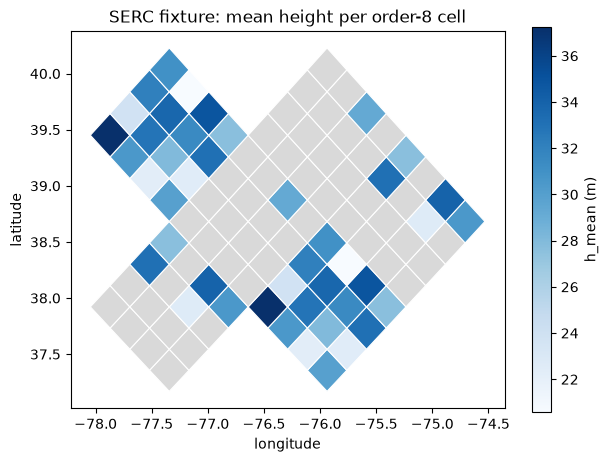

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon

patches = [MplPolygon(np.asarray(p.exterior.coords)) for p in boundaries.values]
pc = PatchCollection(patches, edgecolor="white", linewidth=0.8, cmap="Blues")
pc.set_array(ds["h_mean"].values)
pc.cmap.set_bad("#d9d9d9")

fig, ax = plt.subplots(figsize=(7, 5))
ax.add_collection(pc)
ax.autoscale()
ax.set_aspect("equal")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("SERC fixture: mean height per order-8 cell")
fig.colorbar(pc, ax=ax, label="h_mean (m)")
plt.show()

## Where next

- [Quickstart (prose)](https://espg.github.io/moczarr/quickstart/) —
  the same flow with AOI/empty-coverage semantics spelled out.
- [Concepts](https://espg.github.io/moczarr/concepts/) — the hive tree,
  coverage tiers, and how the lazy index works, with pointers to the
  normative specs.
- [API reference](https://espg.github.io/moczarr/api/open/).